In [ ]:
import torch
import torch.nn as nn
import torch.distributions as D

# Define a simple RNN-based autoregressive model
class SimpleAutoregressiveRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(SimpleAutoregressiveRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.LSTMCell(embedding_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim

    def forward_step(self, x_input_token, h_prev, c_prev):
        embedded = self.embedding(x_input_token).squeeze(1) 
        h_next, c_next = self.rnn(embedded, (h_prev, c_prev))
        logits = self.fc(h_next)
        return logits, h_next, c_next

    def generate(self, start_token_idx, max_len):
        # start_token_idx: scalar tensor, e.g., torch.tensor(0)
        batch_size = 1 # For simplicity, generate one sequence
        generated_sequence = [start_token_idx.item()]
        # Initialize hidden and cell states
        h_t = torch.zeros(batch_size, self.hidden_dim)
        c_t = torch.zeros(batch_size, self.hidden_dim)
        
        current_token = start_token_idx.unsqueeze(0) # Shape: (1, 1)

        with torch.no_grad():
            for _ in range(max_len - 1):
                logits, h_t, c_t = self.forward_step(current_token, h_t, c_t)
                # Sample from the categorical distribution defined by logits
                # Using softmax to get probabilities, then multinomial to sample
                probabilities = torch.softmax(logits, dim=1)
                next_token_dist = D.Categorical(probabilities)
                next_token_pred = next_token_dist.sample()
                
                generated_sequence.append(next_token_pred.item())
                current_token = next_token_pred.unsqueeze(1)
                # if next_token_pred.item() == end_token_id:
                #     break
        return generated_sequence

vocab_size = 10 
embedding_dim = 32
hidden_dim = 64
sequence_to_generate_len = 5

model = SimpleAutoregressiveRNN(vocab_size, embedding_dim, hidden_dim)
model.eval()

# --- Autoregressive Generation Example ---
start_token = torch.tensor(0) # Example: start with token 0
generated_output = model.generate(start_token, sequence_to_generate_len)
print(f"Model definition: {model}")
print(f"Generated sequence (autoregressive sampling): {generated_output}")

Model definition: SimpleAutoregressiveRNN(
  (embedding): Embedding(10, 32)
  (rnn): LSTMCell(32, 64)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)
Generated sequence (autoregressive sampling): [0, 3, 6, 2, 6]


In [ ]:
import torch
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=128):
        super(VAE, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder: p(z|x) - maps x to parameters of q_phi(z|x)
        self.encoder_fc1 = nn.Linear(input_dim, hidden_dim)
        self.encoder_fc_mean = nn.Linear(hidden_dim, latent_dim) # To output mu_phi(x)
        self.encoder_fc_logvar = nn.Linear(hidden_dim, latent_dim) # To output log(sigma_phi(x)^2)

        # Decoder: p(x|z) - maps z to parameters of p_theta(x|z)
        self.decoder_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.decoder_fc_out = nn.Linear(hidden_dim, input_dim) # To output parameters for x

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid() # Assuming binary data (MNIST) for simplicity

    def encode(self, x):
        # x: (batch_size, input_dim)
        h = self.relu(self.encoder_fc1(x))
        mu = self.encoder_fc_mean(h)
        logvar = self.encoder_fc_logvar(h) # log(sigma^2) for numerical stability
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar) # sigma = exp(0.5 * log(sigma^2))
        eps = torch.randn_like(std)   # Sample epsilon from N(0, I)
        return mu + eps * std         # z = mu + sigma * epsilon

    def decode(self, z):
        # z: (batch_size, latent_dim)
        h = self.relu(self.decoder_fc1(z))
        # Pass through sigmoid to get probabilities
        x_recon_probs = self.sigmoid(self.decoder_fc_out(h))
        return x_recon_probs

    def forward(self, x):
        # This forward is typically used during training
        mu, logvar = self.encode(x.view(-1, self.input_dim))
        z = self.reparameterize(mu, logvar)
        x_recon_probs = self.decode(z)
        return x_recon_probs, mu, logvar

    def sample(self, num_samples):
        # Generate samples from the prior p(z) = N(0, I)
        with torch.no_grad():
            z_prior = torch.randn(num_samples, self.latent_dim)
            generated_x_probs = self.decode(z_prior)
            # For binary data, can sample from Bernoulli(generated_x_probs)
        return generated_x_probs

# For a dataset like binarized MNIST, input_dim would be 784 (28x28 pixels)
input_dim = 784
latent_dim = 20 # Dimensionality of the latent space
hidden_dim_vae = 256
vae_model = VAE(input_dim=input_dim, latent_dim=latent_dim, hidden_dim=hidden_dim_vae)
vae_model.eval()

# Assume the model is pre-trained.
num_new_samples = 5
generated_samples_probs = vae_model.sample(num_new_samples)

print(f"Probabilities of {num_new_samples} generated samples (shape: {generated_samples_probs.shape})")


VAE Model definition: VAE(
  (encoder_fc1): Linear(in_features=784, out_features=256, bias=True)
  (encoder_fc_mean): Linear(in_features=256, out_features=20, bias=True)
  (encoder_fc_logvar): Linear(in_features=256, out_features=20, bias=True)
  (decoder_fc1): Linear(in_features=20, out_features=256, bias=True)
  (decoder_fc_out): Linear(in_features=256, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
Probabilities of 5 generated samples (shape: torch.Size([5, 784]))


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Simple Real Data Distribution (e.g., a Gaussian)
def get_real_samples(num_samples):
    # Simple 1D data centered around 5 with some noise
    return torch.randn(num_samples, data_dim) * 0.5 + 5.0

# Generator
class SimpleGenerator(nn.Module):
    def __init__(self, latent_dim, output_dim, hidden_dim):
        super(SimpleGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, z):
        return self.net(z)

# Discriminator
class SimpleDiscriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid() # Output probability
        )
    def forward(self, x):
        return self.net(x)

# Model Initialization
latent_dim = 10    # Latent dimension for the generator
data_dim = 1       # Dimension of the real/fake data
hidden_dim = 32
lr = 0.001
num_epochs = 1000
batch_size = 64
generator = SimpleGenerator(latent_dim, data_dim, hidden_dim)
discriminator = SimpleDiscriminator(data_dim, hidden_dim)

# Optimizers
optimizer_g = optim.Adam(generator.parameters(), lr=lr)
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr)

# Loss Function
criterion = nn.BCELoss()

# Training Loop
for epoch in range(num_epochs):
    # Train Discriminator
    optimizer_d.zero_grad()

    # Real samples
    real_data = get_real_samples(batch_size)
    real_labels = torch.ones(batch_size, 1)
    d_output_real = discriminator(real_data)
    loss_d_real = criterion(d_output_real, real_labels)

    # Fake samples
    noise = torch.randn(batch_size, latent_dim)
    fake_data = generator(noise)
    fake_labels = torch.zeros(batch_size, 1)
    d_output_fake = discriminator(fake_data.detach()) # Detach to avoid training generator
    loss_d_fake = criterion(d_output_fake, fake_labels)

    loss_d = loss_d_real + loss_d_fake
    loss_d.backward()
    optimizer_d.step()

    # Train Generator
    optimizer_g.zero_grad()
    noise = torch.randn(batch_size, latent_dim)
    fake_data_for_g = generator(noise)
    # We want the discriminator to think these are real
    g_output = discriminator(fake_data_for_g)
    loss_g = criterion(g_output, real_labels)
    loss_g.backward()
    optimizer_g.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss D: {loss_d.item():.4f}, Loss G: {loss_g.item():.4f}")

# Generate some samples after training
generator.eval()
with torch.no_grad():
    test_noise = torch.randn(5, latent_dim)
    generated_samples = generator(test_noise)
    print("\nGenerated Samples (after training)")
    print(generated_samples)

    discriminator.eval()
    d_on_generated = discriminator(generated_samples)
    print("\nDiscriminator's opinion on generated samples (closer to 1 is better for G)")
    print(d_on_generated)

    real_test_samples = get_real_samples(5)
    d_on_real = discriminator(real_test_samples)
    print("\nDiscriminator's opinion on real samples (should be close to 1)")
    print(d_on_real)

Epoch [100/1000], Loss D: 0.9344, Loss G: 0.7110
Epoch [200/1000], Loss D: 1.3691, Loss G: 0.7307
Epoch [300/1000], Loss D: 1.5200, Loss G: 0.8771
Epoch [400/1000], Loss D: 1.3349, Loss G: 0.9501
Epoch [500/1000], Loss D: 1.3681, Loss G: 0.6828
Epoch [600/1000], Loss D: 1.3787, Loss G: 0.6359
Epoch [700/1000], Loss D: 1.3752, Loss G: 0.6930
Epoch [800/1000], Loss D: 1.3784, Loss G: 0.7074
Epoch [900/1000], Loss D: 1.3804, Loss G: 0.7021
Epoch [1000/1000], Loss D: 1.3804, Loss G: 0.7133

--- Generated Samples (after training) ---
tensor([[4.8204],
        [5.1293],
        [4.5748],
        [5.0389],
        [5.8960]])

--- Discriminator's opinion on generated samples (closer to 1 is better for G) ---
tensor([[0.4999],
        [0.5003],
        [0.4954],
        [0.5020],
        [0.4856]])

--- Discriminator's opinion on real samples (should be close to 1) ---
tensor([[0.5017],
        [0.5018],
        [0.4992],
        [0.4876],
        [0.4990]])


In [ ]:
import torch
import torch.nn as nn
import math

class SimpleAffineCouplingLayer(nn.Module):
    def __init__(self, data_dim, hidden_dim, split_dim_idx):
        super().__init__()
        self.dim1 = split_dim_idx
        self.dim2 = data_dim - split_dim_idx
        # scale (s)
        self.s_net = nn.Sequential(nn.Linear(self.dim1, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, self.dim2))
        # translation (t)
        self.t_net = nn.Sequential(nn.Linear(self.dim1, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, self.dim2))

    def forward(self, z): # Forward pass: z -> x
        z1, z2 = z.split([self.dim1, self.dim2], dim=1)
        # Compute scale and shift from z1
        log_s = self.s_net(z1)
        t = self.t_net(z1)
        s = torch.exp(log_s)
        # Apply transform to z2
        x1 = z1
        x2 = z2 * s + t
        x_out = torch.cat([x1, x2], dim=1)
        # Log determinant: log |det(dx/dz)| = sum(log(s))
        log_det_jacobian = log_s.sum(dim=1)
        return x_out, log_det_jacobian

    def inverse(self, x): # Inverse pass: x -> z
        x1, x2 = x.split([self.dim1, self.dim2], dim=1)
        # Compute scale and shift from x1
        log_s = self.s_net(x1)
        t = self.t_net(x1)
        s = torch.exp(log_s)
        # Apply inverse transform to x2
        z1 = x1
        z2 = (x2 - t) / s
        z_out = torch.cat([z1, z2], dim=1)
        # Inverse log determinant: log |det(dz/dx)| = - sum(log(s))
        log_det_jacobian_inv = -log_s.sum(dim=1)
        return z_out, log_det_jacobian_inv

data_dim = 4
hidden_dim = 32
split_at = data_dim // 2
# Instantiate the layer
flow_layer = SimpleAffineCouplingLayer(data_dim, hidden_dim, split_at)

# latent variables z from base distribution
z_sample = torch.randn(5, data_dim)

# 1. Forward pass (Sampling)
x_generated, log_det_fwd = flow_layer.forward(z_sample)
print(f"Sampling: z -> x\nInput z:\n{z_sample}\nOutput x:\n{x_generated}\nLogDet(Fwd):\n{log_det_fwd}")

# 2. Inverse pass (Likelihood Prep)
z_reconstructed, log_det_inv = flow_layer.inverse(x_generated)
print(f"\nLikelihood: x -> z\nInput x:\n{x_generated}\nOutput z:\n{z_reconstructed}\nLogDet(Inv):\n{log_det_inv}")

# 3. Likelihood Calculation
# Log prob of z under base distribution (Standard Gaussian N(0,I))
log_prob_z_base = -0.5 * z_reconstructed.pow(2).sum(dim=1) - 0.5 * data_dim * math.log(2 * math.pi)
# Total log-likelihood of x = sum log prob base + log det inverse Jacobian
log_likelihood_x = log_prob_z_base + log_det_inv
print(f"\nLog Likelihood of x:\n{log_likelihood_x}")

Sampling: z -> x
Input z:
tensor([[ 1.7726, -0.0318, -0.2874,  0.4074],
        [ 0.4979, -0.0906,  0.6623, -0.2519],
        [-1.5404,  1.4859, -1.4030, -1.2787],
        [-1.4215, -0.5757,  0.6739, -0.9872],
        [ 0.4841,  0.6681,  0.3637, -0.2562]])
Output x:
tensor([[ 1.7726, -0.0318, -0.5871,  0.1954],
        [ 0.4979, -0.0906,  0.5238, -0.5891],
        [-1.5404,  1.4859, -1.9783, -1.6039],
        [-1.4215, -0.5757,  1.2302, -1.7355],
        [ 0.4841,  0.6681,  0.3133, -0.7506]], grad_fn=<CatBackward0>)
LogDet(Fwd):
tensor([0.2945, 0.2133, 0.6285, 0.4922, 0.5388], grad_fn=<SumBackward1>)

Likelihood: x -> z
Input x:
tensor([[ 1.7726, -0.0318, -0.5871,  0.1954],
        [ 0.4979, -0.0906,  0.5238, -0.5891],
        [-1.5404,  1.4859, -1.9783, -1.6039],
        [-1.4215, -0.5757,  1.2302, -1.7355],
        [ 0.4841,  0.6681,  0.3133, -0.7506]], grad_fn=<CatBackward0>)
Output z:
tensor([[ 1.7726, -0.0318, -0.2874,  0.4074],
        [ 0.4979, -0.0906,  0.6623, -0.2519],
      

Epoch 1, Step 1/469, Loss: 1.3651
Epoch 1, Step 11/469, Loss: 0.9951
Epoch 1, Step 21/469, Loss: 0.9309
Epoch 1, Step 31/469, Loss: 0.5947
Epoch 1, Step 41/469, Loss: 0.3525
Epoch 1, Step 51/469, Loss: 0.2814
Epoch 1, Step 61/469, Loss: 0.2310
Epoch 1, Step 71/469, Loss: 0.1954
Epoch 1, Step 81/469, Loss: 0.1755
Epoch 1, Step 91/469, Loss: 0.1591
Epoch 1, Step 101/469, Loss: 0.1796
Epoch 1, Step 111/469, Loss: 0.1835
Epoch 1, Step 121/469, Loss: 0.1398
Epoch 1, Step 131/469, Loss: 0.1241
Epoch 1, Step 141/469, Loss: 0.1164
Epoch 1, Step 151/469, Loss: 0.1036
Epoch 1, Step 161/469, Loss: 0.1051
Epoch 1, Step 171/469, Loss: 0.1249
Epoch 1, Step 181/469, Loss: 0.1073
Epoch 1, Step 191/469, Loss: 0.1246
Epoch 1, Step 201/469, Loss: 0.0934
Epoch 1, Step 211/469, Loss: 0.0911
Epoch 1, Step 221/469, Loss: 0.1109
Epoch 1, Step 231/469, Loss: 0.1016
Epoch 1, Step 241/469, Loss: 0.0707
Epoch 1, Step 251/469, Loss: 0.0944
Epoch 1, Step 261/469, Loss: 0.0664
Epoch 1, Step 271/469, Loss: 0.0809
Epo

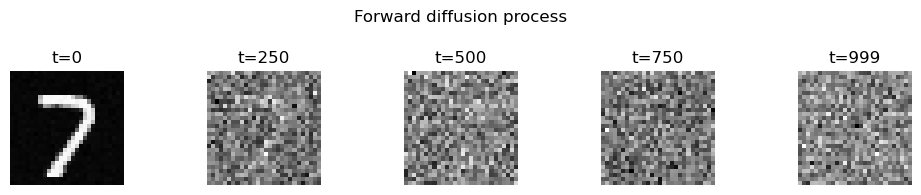

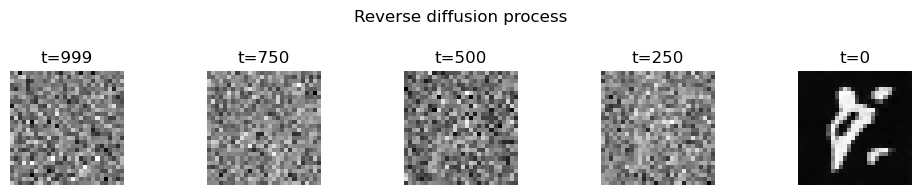

In [49]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import math
from torch.utils.data import DataLoader

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Example MNIST loader for demo
dataloader = DataLoader(
    datasets.MNIST('data', train=True, download=True,
                   transform=transforms.ToTensor()),
    batch_size=128, shuffle=True
)

# Hyperparameters & schedules
T = 1000
betas = torch.linspace(0.0001, 0.02, T, device=device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]])
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

# Forward diffusion
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sa = sqrt_alphas_cumprod[t].view(-1,1,1,1).to(x0.device)
    sb = sqrt_one_minus_alphas_cumprod[t].view(-1,1,1,1).to(x0.device)
    return sa * x0 + sb * noise

# Single reverse step
@torch.no_grad()
def p_sample(model, xt, t):
    pred_noise = model(xt, t)
    a = alphas[t].view(-1,1,1,1).to(xt.device)
    b = betas[t].view(-1,1,1,1).to(xt.device)
    sb = sqrt_one_minus_alphas_cumprod[t].view(-1,1,1,1).to(xt.device)
    mean = (1/torch.sqrt(a)) * (xt - (b/sb)*pred_noise)
    if t == 0:
        return mean
    var = posterior_variance[t].view(-1,1,1,1).to(xt.device)
    return mean + torch.sqrt(var) * torch.randn_like(xt)

# Full reverse sampling
@torch.no_grad()
def p_sample_loop(model, shape, record_ts):
    img = torch.randn(shape, device=next(model.parameters()).device)
    intermediates = []
    for t in reversed(range(T)):
        img = p_sample(model, img, torch.tensor([t], device=img.device))
        if t in record_ts:
            intermediates.append(img[0].cpu().clone())
    return img.cpu(), intermediates

# Sinusoidal time embedding
def get_timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(0, half, device=t.device) / (half - 1)
    )  # [half]
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)  # [batch, half]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

# Dummy noise predictor
class NoisePredictor(nn.Module):
    def __init__(self, C=1, hidden=32, t_dim=32, num_layers=1):
        super().__init__()
        self.t_dim = t_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(t_dim, hidden),
            nn.ReLU()
        )
        self.input_conv = nn.Conv2d(C, hidden, 3, padding=1)
        self.res_blocks = nn.ModuleList([
            nn.Conv2d(hidden, hidden, 3, padding=1) for _ in range(num_layers)
        ])
        self.output_conv = nn.Conv2d(hidden, C, 3, padding=1)

    def forward(self, x, t):
        # x: [B, C, H, W], t: [B] long
        t_emb = get_timestep_embedding(t, self.t_dim)           # [B, t_dim]
        t_emb = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)  # [B, hidden, 1, 1]
        h = torch.relu(self.input_conv(x) + t_emb)
        for block in self.res_blocks:
            h = torch.relu(block(h) + h)
        return self.output_conv(h)

model = NoisePredictor(hidden=128, num_layers=12).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 10
# (Optional) Quick toy training loop
for epoch in range(epochs):
    for step, (x0, _) in enumerate(dataloader):
        x0 = x0.to(device)
        t = torch.randint(0, T, (x0.size(0),), device=device)
        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise)
        pred = model(xt, t)
        loss = nn.functional.mse_loss(pred, noise)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        if step % 10 == 0:
            print(f"Epoch {epoch+1}, Step {step+1}/{len(dataloader)}, Loss: {loss.item():.4f}")

# Visualization of forward & reverse
x0, _ = next(iter(dataloader))
x0 = x0.to(device)
timesteps = [0, T//4, T//2, 3*T//4, T-1]

# Forward noising
noisy_imgs = []
for t in timesteps:
    t_batch = torch.full((x0.size(0),), t, device=device, dtype=torch.long)
    noisy_imgs.append(q_sample(x0, t_batch)[0].cpu())

plt.figure(figsize=(10,2))
for i, img in enumerate(noisy_imgs):
    plt.subplot(1, len(timesteps), i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"t={timesteps[i]}")
    plt.axis('off')
plt.suptitle("Forward diffusion process")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for suptitle
plt.show()

# Reverse denoising (from t=T-1 back to selected lower t's)
gen_img, inter_img = p_sample_loop(model, (1,1,28,28), timesteps)

plt.figure(figsize=(10,2))
for i, img in enumerate(inter_img):
    plt.subplot(1, len(inter_img), i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"t={timesteps[::-1][i]}")
    plt.axis('off')
plt.suptitle("Reverse diffusion process")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
